In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, gaussian_kde
import cvxpy as cp
from torch.special import erf
from math import sqrt, pi
from torch.linalg import det, inv
import torch as th
from torch import Tensor
from torch.distributions.multivariate_normal import MultivariateNormal
from scipy.spatial import ConvexHull
from serl_sprl.sets import Zonotope
from cvxpylayers.torch import CvxpyLayer
from serl_sprl.visualization_densities.helpers import *

Let's first plot the probability density of the unprojected distribution over a zonotopic safe action set in 2-dimensional space. 

In [2]:
# --- Seeding ---
np.random.seed(42)
th.manual_seed(42)
# Reward function offset
offset = th.tensor([-0.5, -0.5])
# --- Parameters ---
# Policy parameters
mu = th.tensor([-0.5, -2.5], requires_grad=True)
log_variance = th.tensor([0.0, 0.0], requires_grad=True)  # Use log-variance for numerical stability

# Create a random zonotope in 2D
center = np.array([0.0, 0.0])
zono = Zonotope.from_random(n_d=center.shape[0], n_g=6, c=center)

# Create CVXPY layer for projection
projection_layer = create_layer_safe_action_set(zono.c, zono.G)

# Convert to variance and create covariance matrix
variance = th.exp(log_variance)
cov = th.diag_embed(variance)

N = 20000
# --- Sample points ---
dist = MultivariateNormal(mu, cov)
samples = dist.sample((N,))
# --- Project samples to safe set ---
projected_samples = projection_layer(samples, th.tensor(zono.c.flatten(), dtype=th.float32), th.tensor(zono.G, dtype=th.float32))[0]

In [3]:
# --- Kernel density estimate from samples ---
x, y = np.mgrid[-4:4:100j, -4:4:100j]
kde = gaussian_kde(samples.detach().cpu().numpy().T)
kde_pdf = kde(np.vstack([x.ravel(), y.ravel()])).reshape(x.shape)
# --- Kernel density estimate from projected samples ---
kde_proj = gaussian_kde(projected_samples.detach().cpu().numpy().T)
kde_proj_pdf = kde_proj(np.vstack([x.ravel(), y.ravel()])).reshape(x.shape)

In [4]:
# --- Estimate densities of projected samples (batched) ---
projection_distance = th.norm(projected_samples - samples, dim=1)
projected_mask = projection_distance >= 1e-5
normal_vectors = (samples - projected_samples) / projection_distance.unsqueeze(1)
normal_vectors = th.where(projection_distance.unsqueeze(1) < 1e-6, th.ones_like(normal_vectors), normal_vectors)
boundary_densities = compute_gaussian_boundary_mass_torch(
    mu, variance, 
    projected_samples, 
    normal_vectors, 
    t_max=2.0
    )
hybrid_log_prob = th.where(projected_mask, th.log(boundary_densities), dist.log_prob(samples))

integral.max(): tensor(0.2695, grad_fn=<MaxBackward1>)
integral.min(): tensor(5.5017e-05, grad_fn=<MinBackward1>)


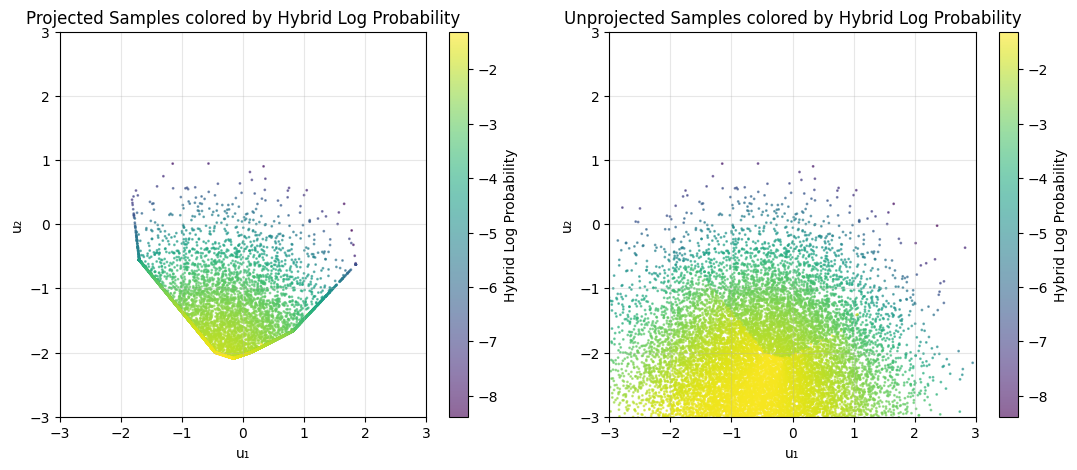

In [5]:
# --- Plot the hybrid log prob ---
fig, ax = plt.subplots(figsize=(13, 5), ncols=2)

# Convert to numpy for plotting
samples_np = samples.detach().cpu().numpy()
projected_samples_np = projected_samples.detach().cpu().numpy()
hybrid_log_prob_np = hybrid_log_prob.detach().cpu().numpy()

# Plot 1: Scatter plot of projected samples colored by hybrid log prob
scatter = ax[0].scatter(projected_samples_np[:, 0], projected_samples_np[:, 1], 
                       c=hybrid_log_prob_np, cmap='viridis', alpha=0.6, s=1)
# plot_circle(ax[0], center=center, radius=radius)
ax[0].set_title('Projected Samples colored by Hybrid Log Probability')
ax[0].set_xlabel('u₁')
ax[0].set_ylabel('u₂')
ax[0].set_xlim([-3, 3])
ax[0].set_ylim([-3, 3])
ax[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter, ax=ax[0])
cbar1.set_label('Hybrid Log Probability')

# Plot 2: Hybrid log prob over unprojected samples
scatter = ax[1].scatter(samples_np[:, 0], samples_np[:, 1], 
                       c=hybrid_log_prob_np, cmap='viridis', alpha=0.6, s=1)
# plot_circle(ax[1], center=center, radius=radius)
ax[1].set_title('Unprojected Samples colored by Hybrid Log Probability')
ax[1].set_xlabel('u₁')
ax[1].set_ylabel('u₂')
ax[1].set_xlim([-3, 3])
ax[1].set_ylim([-3, 3])
ax[1].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter, ax=ax[1])
cbar1.set_label('Hybrid Log Probability')

In [6]:
def reward_function(samples: th.Tensor, offset: th.Tensor) -> th.Tensor:
    return - th.norm(samples - offset, dim=1)

In [7]:
unproj_loss_samples = reward_function(projected_samples, offset=offset) * dist.log_prob(samples)
proj_loss_samples = reward_function(projected_samples, offset=offset) * hybrid_log_prob
unprojected_loss = th.mean(unproj_loss_samples)
projected_loss = th.mean(proj_loss_samples)

Let's plot the loss over our grid for comparison: 

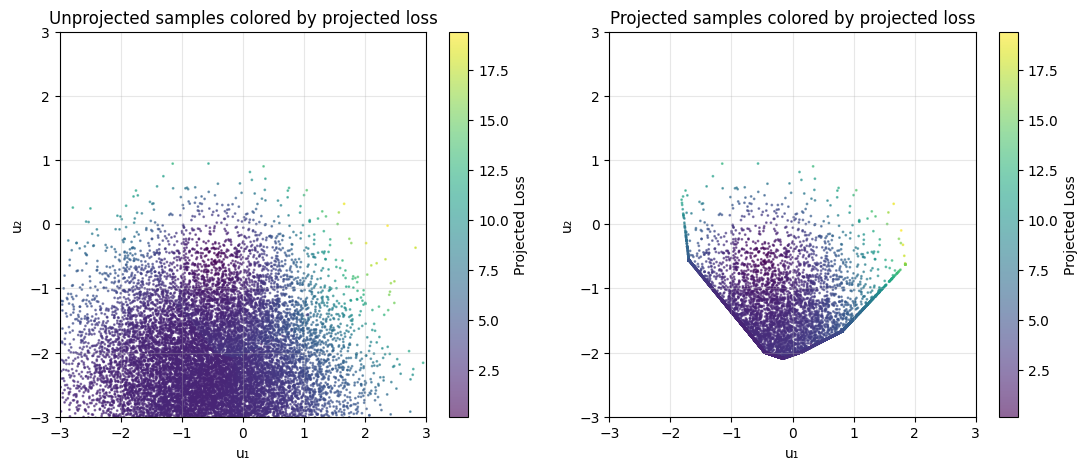

In [8]:
# --- Plot the loss ---
fig, ax = plt.subplots(figsize=(13, 5), ncols=2)

# Convert to numpy for plotting
unproj_loss_np = unproj_loss_samples.detach().cpu().numpy()
proj_loss_np = proj_loss_samples.detach().cpu().numpy()

# Plot 1: Scatter plot of projected samples colored by hybrid log prob
scatter = ax[0].scatter(samples_np[:, 0], samples_np[:, 1], 
                       c=proj_loss_np, cmap='viridis', alpha=0.6, s=1)
# plot_circle(ax[0], center=center, radius=radius)
ax[0].set_title('Unprojected samples colored by projected loss')
ax[0].set_xlabel('u₁')
ax[0].set_ylabel('u₂')
ax[0].set_xlim([-3, 3])
ax[0].set_ylim([-3, 3])
ax[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter, ax=ax[0])
cbar1.set_label('Projected Loss')

# Plot 2: Hybrid log prob over unprojected samples
scatter = ax[1].scatter(projected_samples_np[:, 0], projected_samples_np[:, 1], 
                       c=proj_loss_np, cmap='viridis', alpha=0.6, s=1)
# plot_circle(ax[1], center=center, radius=radius)
ax[1].set_title('Projected samples colored by projected loss')
ax[1].set_xlabel('u₁')
ax[1].set_ylabel('u₂')
ax[1].set_xlim([-3, 3])
ax[1].set_ylim([-3, 3])
ax[1].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter, ax=ax[1])
cbar1.set_label('Projected Loss')

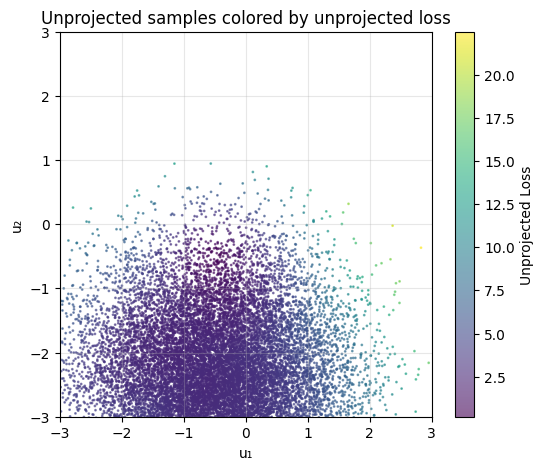

In [9]:
# --- Plot the loss ---
fig, ax = plt.subplots(figsize=(6, 5), ncols=1)

# Convert to numpy for plotting
unproj_loss_np = unproj_loss_samples.detach().cpu().numpy()
proj_loss_np = proj_loss_samples.detach().cpu().numpy()

# Plot 1: Scatter plot of projected samples colored by hybrid log prob
scatter = ax.scatter(samples_np[:, 0], samples_np[:, 1], 
                       c=unproj_loss_np, cmap='viridis', alpha=0.6, s=1)
# plot_circle(ax[0], center=center, radius=radius)
ax.set_title('Unprojected samples colored by unprojected loss')
ax.set_xlabel('u₁')
ax.set_ylabel('u₂')
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])
ax.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter, ax=ax)
cbar1.set_label('Unprojected Loss')

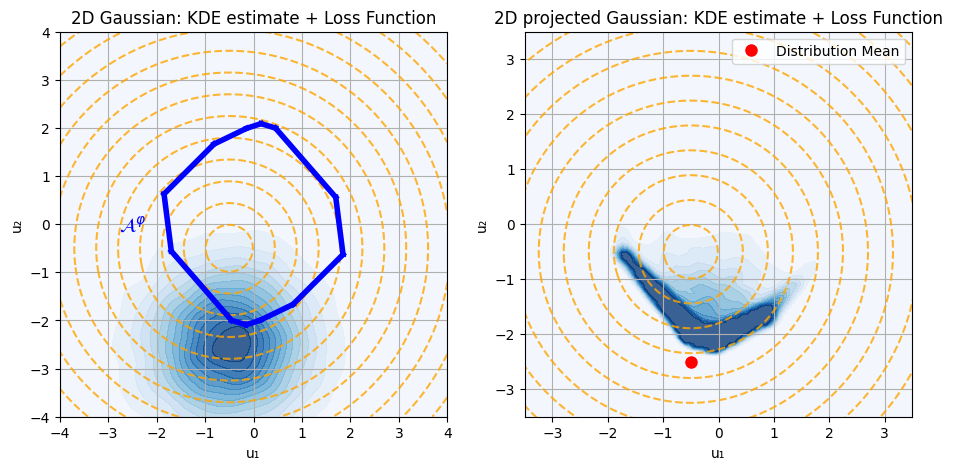

In [10]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 5), ncols=2)

# Compute loss function values on the grid
x_grid, y_grid = np.mgrid[-4:4:100j, -4:4:100j]
grid_points = th.tensor(np.stack([x_grid.ravel(), y_grid.ravel()], axis=1), dtype=th.float32)
loss_values = reward_function(grid_points, offset=offset).detach().cpu().numpy().reshape(x_grid.shape)

# Determine common levels based on both KDE estimates
vmin = kde_pdf.min()
vmax = kde_pdf.max()
levels = np.linspace(vmin, vmax, 15)

# Loss function levels
loss_min = loss_values.min()
loss_max = loss_values.max()
loss_levels = np.linspace(loss_min, loss_max, 15)

# limit values in kde_proj_pdf to [vmin, vmax] for consistent contour levels
kde_proj_pdf_clipped = np.clip(kde_proj_pdf, vmin, vmax)

# Filled KDE contour from samples
ax[0].contourf(x, y, kde_pdf, levels=levels, cmap='Blues', alpha=0.8)
# Add loss function contourrewards in orange
ax[0].contour(x_grid, y_grid, loss_values, levels=loss_levels, colors='orange', alpha=0.8, linewidths=1.5)
plot_shape(ax[0], zono.vertices, label=r'$\mathcal{U}^\varphi$', color='blue')

ax[0].set_title('2D Gaussian: KDE estimate + Loss Function')
ax[0].set_xlabel('u₁')
ax[0].set_ylabel('u₂')
ax[1].set_ylim([-4, 3.5])
ax[1].set_xlim([-4, 3.5])
ax[0].grid(True)

# Add annotation for the circle
ax[0].annotate(r'$\mathcal{A}^\varphi$', 
               xy=(-2.5, 0),  
               fontsize=14, 
               color='blue', 
               weight='bold',
               ha='center', va='center')

# Filled KDE contour from projected samples
ax[1].contourf(x, y, kde_proj_pdf_clipped, levels=levels, cmap='Blues', alpha=0.8)
# Add loss function contours in orange
ax[1].contour(x_grid, y_grid, loss_values, levels=loss_levels, colors='orange', alpha=0.8, linewidths=1.5)
# plot mean
ax[1].plot(mu[0].detach().cpu().numpy(), mu[1].detach().cpu().numpy(), 'ro', markersize=8, label='Distribution Mean')

ax[1].set_title('2D projected Gaussian: KDE estimate + Loss Function')
ax[1].set_xlabel('u₁')
ax[1].set_ylabel('u₂')
ax[1].set_ylim([-3.5, 3.5])
ax[1].set_xlim([-3.5, 3.5])
ax[1].grid(True)
ax[1].legend()

plt.show()

In [11]:
# Replace the relevant parts in your optimization cell

# Multi-step optimization with parallel unprojected and projected policies
n_steps = 30
n_samples = 2000
lr = 0.5

# Enhancements
psl = False
pen_c = False
penalty_factor = 1.0

# ============ CHANGE 1: Initialize with unsquashed parameters ============
# Compute the initial unsquashed mean using inverse tanh (arctanh)
# For points inside [-1, 1], arctanh maps them to (-inf, inf)
# First, scale mu to be within tanh's effective range
scale = 3.0
mu_init = mu.clone()
# Ensure mu is within valid range for arctanh (strict bounds: -1 < x < 1)
mu_init_scaled = th.clamp(mu_init / scale, -0.99, 0.99)  # Scale to fit in safe range
mu_unsquashed_init = th.atanh(mu_init_scaled) * scale  # Inverse and scale back

# Parameters are now unsquashed
mu_unproj_unsquashed = th.tensor(mu_unsquashed_init.clone(), requires_grad=True)
log_var_unproj = th.tensor([0.0, 0.0], requires_grad=True)
mu_proj_unsquashed = th.tensor(mu_unsquashed_init.clone(), requires_grad=True)
log_var_proj = th.tensor([0.0, 0.0], requires_grad=True)

# ============ CHANGE 2: Define the squashing function ============
def squash_mean(mu_unsquashed, scale=3.0):
    """Apply tanh squashing to get the actual mean"""
    return scale * th.tanh(mu_unsquashed / scale)

# Get the initial squashed mean for plotting
mu_start = squash_mean(mu_unproj_unsquashed).clone().detach()

# Storage for tracking evolution
mu_unproj_history = []
mu_proj_history = []
loss_unproj_history = []
loss_proj_history = []

print("Starting multi-step optimization...")
print(f"Target location: {offset.numpy()}")
print(f"Initial mean (unsquashed): {mu_unproj_unsquashed.detach().numpy()}")
print(f"Initial mean (squashed): {mu_start.numpy()}")
print(f"Learning rate: {lr}")
print(f"Samples per iteration: {n_samples}")
print("-" * 50)

for step in range(n_steps):
    print(f"Step {step + 1}/{n_steps}")
    
    # ============ CHANGE 3: Apply squashing in forward pass ============
    # Unprojected policy
    mu_unproj = squash_mean(mu_unproj_unsquashed)
    
    # Create distribution and sample
    cov_unproj = th.diag_embed(th.exp(log_var_unproj))
    dist_unproj = MultivariateNormal(mu_unproj, cov_unproj)
    samples_unproj = dist_unproj.sample((n_samples,))
    
    # Project samples (for consistent reward evaluation)
    projected_samples_unproj = projection_layer(
        samples_unproj, 
        th.tensor(zono.c.flatten(), dtype=th.float32), 
        th.tensor(zono.G, dtype=th.float32)
    )[0]
    
    # Compute unprojected loss (reward * unprojected log prob)
    unproj_values = reward_function(projected_samples_unproj, offset=offset)
    if pen_c:
        unproj_values -= penalty_factor * th.norm(samples_unproj - projected_samples_unproj, dim=1)**2
    unproj_rewards = unproj_values * dist_unproj.log_prob(samples_unproj)
    loss_unproj = th.mean(unproj_rewards)
    if psl:
        proj_mean = projection_layer(
            mu_unproj.unsqueeze(0), 
            th.tensor(zono.c.flatten(), dtype=th.float32), 
            th.tensor(zono.G, dtype=th.float32)
        )[0].squeeze(0)
        loss_unproj -= penalty_factor * th.norm(proj_mean - mu_unproj)**2
    
    # Backward pass for unprojected policy
    loss_unproj.backward()
    
    # Store gradients and update
    mu_grad_unproj = mu_unproj_unsquashed.grad.clone()
    log_var_grad_unproj = log_var_unproj.grad.clone()
    
    with th.no_grad():
        mu_unproj_unsquashed += lr * mu_grad_unproj
        log_var_unproj += lr * log_var_grad_unproj
    
    # Clear gradients
    mu_unproj_unsquashed.grad.zero_()
    log_var_unproj.grad.zero_()
    
    # ============ PROJECTED POLICY ============
    mu_proj = squash_mean(mu_proj_unsquashed)
    
    # Create distribution and sample
    cov_proj = th.diag_embed(th.exp(log_var_proj))
    dist_proj = MultivariateNormal(mu_proj, cov_proj)
    samples_proj = dist_proj.sample((n_samples,))
    
    # Project samples
    projected_samples_proj = projection_layer(
        samples_proj, 
        th.tensor(zono.c.flatten(), dtype=th.float32), 
        th.tensor(zono.G, dtype=th.float32)
    )[0]
    
    # Compute hybrid log probabilities
    projection_distance = th.norm(projected_samples_proj - samples_proj, dim=1)
    projected_mask = projection_distance >= 1e-5
    normal_vectors = (samples_proj - projected_samples_proj) / projection_distance.unsqueeze(1)
    normal_vectors = th.where(projection_distance.unsqueeze(1) < 1e-6, th.ones_like(normal_vectors), normal_vectors)
    boundary_densities = compute_gaussian_boundary_mass_torch(
        mu_proj,
        th.exp(log_var_proj),
        boundary_points=projected_samples_proj,
        normals=normal_vectors,
        t_max=10.0
    )
    hybrid_log_prob = th.where(projected_mask, th.log(boundary_densities), dist_proj.log_prob(samples_proj))
    
    # Compute projected loss (reward * hybrid log prob)
    values = reward_function(projected_samples_proj, offset=offset)
    proj_rewards = values * hybrid_log_prob
    if pen_c:
        penalty_values = penalty_factor * th.norm(samples_proj - projected_samples_proj, dim=1)**2
        proj_rewards -= penalty_values * dist_proj.log_prob(samples_proj)
    loss_proj = th.mean(proj_rewards)

    if psl:
        proj_mean_proj = projection_layer(
            mu_proj.unsqueeze(0), 
            th.tensor(zono.c.flatten(), dtype=th.float32), 
            th.tensor(zono.G, dtype=th.float32)
        )[0].squeeze(0)
        loss_proj -= penalty_factor * th.norm(proj_mean_proj - mu_proj)**2
    
    # Backward pass for projected policy
    loss_proj.backward()
    
    # Store gradients and update
    mu_grad_proj = mu_proj_unsquashed.grad.clone()
    log_var_grad_proj = log_var_proj.grad.clone()
    
    with th.no_grad():
        mu_proj_unsquashed += lr * mu_grad_proj
        log_var_proj += lr * log_var_grad_proj
    
    # Clear gradients
    mu_proj_unsquashed.grad.zero_()
    log_var_proj.grad.zero_()
    
    # ============ STORE RESULTS (squashed values for plotting) ============
    mu_unproj_history.append(mu_unproj.clone().detach())
    mu_proj_history.append(mu_proj.clone().detach())
    loss_unproj_history.append(loss_unproj.item())
    loss_proj_history.append(loss_proj.item())
    
    # Print progress (show both squashed and unsquashed)
    print(f"  Unprojected: μ_squashed = [{mu_unproj[0]:.3f}, {mu_unproj[1]:.3f}], "
          f"μ_unsquashed = [{mu_unproj_unsquashed[0]:.3f}, {mu_unproj_unsquashed[1]:.3f}], "
          f"loss = {loss_unproj.item():.4f}")
    print(f"  Projected:   μ_squashed = [{mu_proj[0]:.3f}, {mu_proj[1]:.3f}], "
          f"μ_unsquashed = [{mu_proj_unsquashed[0]:.3f}, {mu_proj_unsquashed[1]:.3f}], "
          f"loss = {loss_proj.item():.4f}")
    print()

print("Optimization complete!")
print(f"Final unprojected mean (squashed):   [{mu_unproj[0]:.3f}, {mu_unproj[1]:.3f}]")
print(f"Final unprojected mean (unsquashed): [{mu_unproj_unsquashed[0]:.3f}, {mu_unproj_unsquashed[1]:.3f}]")
print(f"Final unprojected covariance: [{th.exp(log_var_unproj)[0]:.3f}, {th.exp(log_var_unproj)[1]:.3f}]")
print(f"Final projected mean (squashed):     [{mu_proj[0]:.3f}, {mu_proj[1]:.3f}]")
print(f"Final projected mean (unsquashed):   [{mu_proj_unsquashed[0]:.3f}, {mu_proj_unsquashed[1]:.3f}]")
print(f"Final projected covariance:   [{th.exp(log_var_proj)[0]:.3f}, {th.exp(log_var_proj)[1]:.3f}]")
print(f"Target location: {offset.numpy()}")

/tmp/ipykernel_40223/2739660815.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu_unproj_unsquashed = th.tensor(mu_unsquashed_init.clone(), requires_grad=True)
/tmp/ipykernel_40223/2739660815.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu_proj_unsquashed = th.tensor(mu_unsquashed_init.clone(), requires_grad=True)


Starting multi-step optimization...
Target location: [-0.5 -0.5]
Initial mean (unsquashed): [-0.50470835 -3.5968428 ]
Initial mean (squashed): [-0.5 -2.5]
Learning rate: 0.5
Samples per iteration: 2000
--------------------------------------------------
Step 1/30
integral.max(): tensor(0.3847, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0001, grad_fn=<MinBackward1>)
  Unprojected: μ_squashed = [-0.500, -2.500], μ_unsquashed = [-0.594, -3.567], loss = 3.9893
  Projected:   μ_squashed = [-0.500, -2.500], μ_unsquashed = [-0.605, -3.604], loss = 2.7149

Step 2/30
integral.max(): tensor(0.2947, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0002, grad_fn=<MinBackward1>)
  Unprojected: μ_squashed = [-0.587, -2.491], μ_unsquashed = [-0.663, -3.540], loss = 3.9598
  Projected:   μ_squashed = [-0.597, -2.502], μ_unsquashed = [-0.697, -3.604], loss = 2.6376

Step 3/30
integral.max(): tensor(0.2893, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0001, grad_fn=<MinBackward1>)
  Unprojected

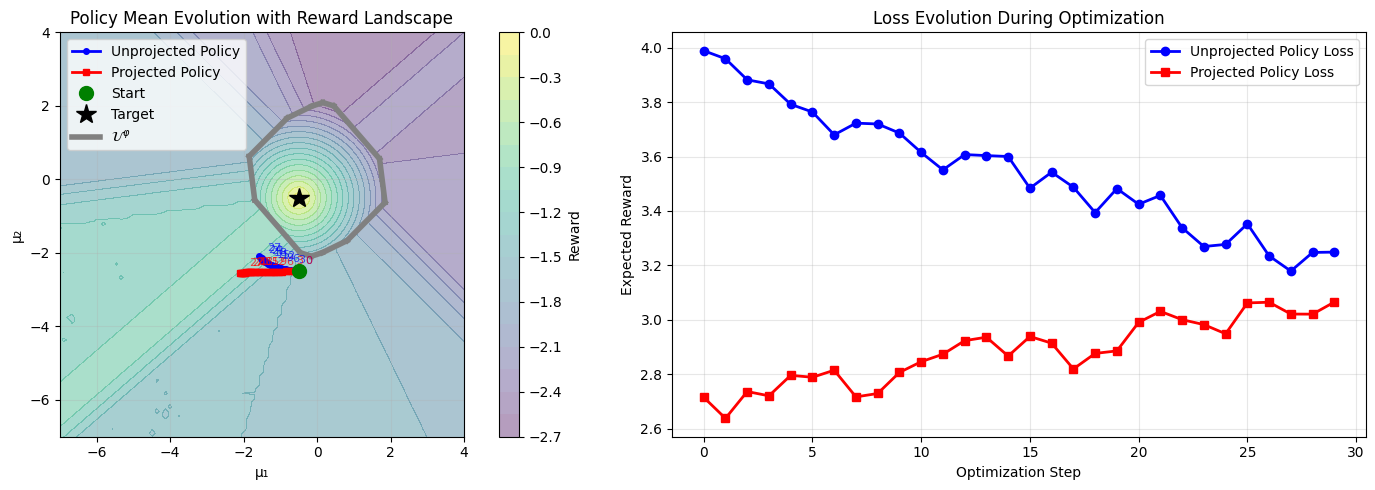


OPTIMIZATION SUMMARY
Distance from target at start:
  Unprojected: 2.000
  Projected:   2.000

Distance from target at end:
  Unprojected: 1.911
  Projected:   2.600

Final expected rewards:
  Unprojected: 3.2488
  Projected:   3.0652

Improvement over 30 steps:
  Unprojected: -0.7405
  Projected:   0.3503


In [12]:
# Replace the plotting cell in density_vis_zonotopes.ipynb

# Plot the evolution of both policies
fig, axes = plt.subplots(figsize=(15, 5), ncols=2)

# Convert histories to numpy for plotting
mu_unproj_np = th.stack(mu_unproj_history).detach().cpu().numpy()
mu_proj_np = th.stack(mu_proj_history).detach().cpu().numpy()

# Plot 1: Trajectory in 2D space with reward landscape
ax = axes[0]

# Create a grid for the reward landscape
u1_grid = np.linspace(-8, 4, 100)
u2_grid = np.linspace(-8, 4, 100)
U1, U2 = np.meshgrid(u1_grid, u2_grid)

# Compute rewards on the grid
grid_points = th.tensor(np.stack([U1.ravel(), U2.ravel()], axis=1), dtype=th.float32)
# Project grid actions to safe set for fair evaluation
projected_grid_points = projection_layer(
    grid_points,
    th.tensor(zono.c.flatten(), dtype=th.float32),
    th.tensor(zono.G, dtype=th.float32)
)[0]
# Compute rewards
rewards_grid = reward_function(projected_grid_points, offset=offset)
rewards_grid = rewards_grid.detach().cpu().numpy().reshape(U1.shape)

# Plot reward landscape as colormap
contour = ax.contourf(U1, U2, rewards_grid, levels=20, cmap='viridis', alpha=0.4)
cbar = plt.colorbar(contour, ax=ax, label='Reward')

# Plot trajectories on top
ax.plot(mu_unproj_np[:, 0], mu_unproj_np[:, 1], 'b-o', label='Unprojected Policy', linewidth=2, markersize=4, zorder=3)
ax.plot(mu_proj_np[:, 0], mu_proj_np[:, 1], 'r-s', label='Projected Policy', linewidth=2, markersize=4, zorder=3)

# Mark start and end points
ax.plot(mu_start[0], mu_start[1], 'go', markersize=10, label='Start', zorder=4)
ax.plot(offset[0], offset[1], 'k*', markersize=15, label='Target', zorder=4)

# Add zonotope boundary
plot_shape(ax, zono.vertices, label=r'$\mathcal{U}^\varphi$', color='grey')
ax.set_xlabel('μ₁')
ax.set_ylabel('μ₂')
ax.set_title('Policy Mean Evolution with Reward Landscape')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim([-7, 4])
ax.set_ylim([-7, 4])
ax.set_aspect('equal')

# Add step numbers (optional - every other step to avoid clutter)
for i in range(0, len(mu_unproj_np), max(1, len(mu_unproj_np)//10)):
    ax.annotate(f'{i}', (mu_unproj_np[i, 0], mu_unproj_np[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='blue', alpha=0.7)
    ax.annotate(f'{i}', (mu_proj_np[i, 0], mu_proj_np[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='red', alpha=0.7)

# Plot 2: Loss evolution over time
ax = axes[1]
ax.plot(range(len(loss_unproj_history)), loss_unproj_history, 'b-o', label='Unprojected Policy Loss', linewidth=2)
ax.plot(range(len(loss_proj_history)), loss_proj_history, 'r-s', label='Projected Policy Loss', linewidth=2)
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Expected Reward')
ax.set_title('Loss Evolution During Optimization')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("OPTIMIZATION SUMMARY")
print("="*60)
print(f"Distance from target at start:")
print(f"  Unprojected: {th.norm(mu_start - offset):.3f}")
print(f"  Projected:   {th.norm(mu_start - offset):.3f}")

print(f"\nDistance from target at end:")
print(f"  Unprojected: {th.norm(mu_unproj - offset):.3f}")
print(f"  Projected:   {th.norm(mu_proj - offset):.3f}")

print(f"\nFinal expected rewards:")
print(f"  Unprojected: {loss_unproj_history[-1]:.4f}")
print(f"  Projected:   {loss_proj_history[-1]:.4f}")

improvement_unproj = loss_unproj_history[-1] - loss_unproj_history[0]
improvement_proj = loss_proj_history[-1] - loss_proj_history[0]
print(f"\nImprovement over {n_steps} steps:")
print(f"  Unprojected: {improvement_unproj:.4f}")
print(f"  Projected:   {improvement_proj:.4f}")

In [13]:
# --- Sampling and density estimation after multi-step optimization ---
# Unprojected update
dist_unprojected = MultivariateNormal(mu_unproj.detach(), cov_unproj.detach())
samples_unprojected = dist_unprojected.sample((N,))
kde_unprojected = gaussian_kde(samples_unprojected.detach().cpu().numpy().T)
kde_unprojected_pdf = kde_unprojected(np.vstack([x.ravel(), y.ravel()])).reshape(x.shape)
# Projected update
dist_projected = MultivariateNormal(mu_proj.detach(), cov_proj.detach())
samples_projected = dist_projected.sample((N,))
projected_samples_projected = projection_layer(samples_projected, th.tensor(zono.c.flatten(), dtype=th.float32), th.tensor(zono.G, dtype=th.float32))[0]
kde_projected = gaussian_kde(projected_samples_projected.detach().cpu().numpy().T)
kde_projected_pdf = kde_projected(np.vstack([x.ravel(), y.ravel()])).reshape(x.shape)


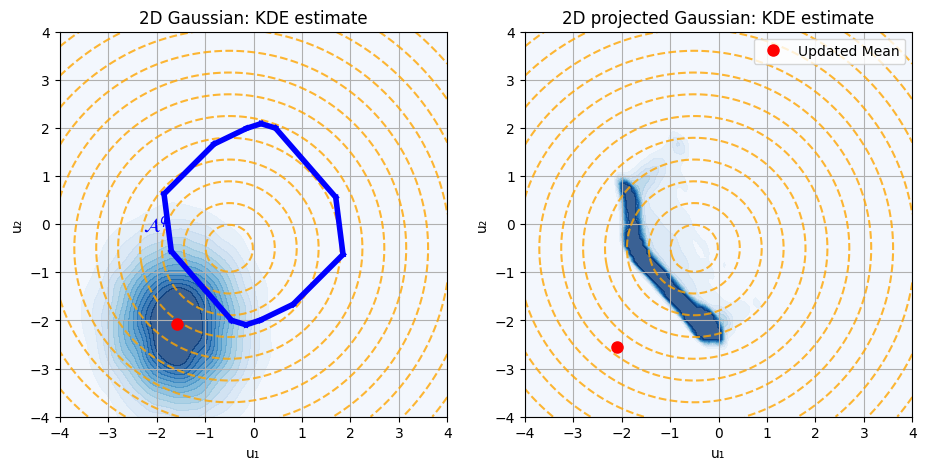

In [14]:
# --- Plotting the final distributions ---
fig, ax = plt.subplots(figsize=(11, 5), ncols=2)

# limit values in kde_proj_pdf to [vmin, vmax] for consistent contour levels
kde_unproj_pdf_clipped = np.clip(kde_unprojected_pdf, vmin, vmax)
kde_proj_pdf_clipped = np.clip(kde_projected_pdf, vmin, vmax)

# Filled KDE contour from samples
ax[0].contourf(x, y, kde_unproj_pdf_clipped, levels=levels, cmap='Blues', alpha=0.8)
# Add loss function contours in orange
ax[0].contour(x_grid, y_grid, loss_values, levels=loss_levels, colors='orange', alpha=0.8, linewidths=1.5)
plot_shape(ax[0], zono.vertices, label=r'$\mathcal{U}^\varphi$', color='blue')
# plot new mean
ax[0].plot(mu_unproj[0].detach().cpu().numpy(), mu_unproj[1].detach().cpu().numpy(), 'ro', markersize=8, label='Updated Mean')

ax[0].set_title('2D Gaussian: KDE estimate')
ax[0].set_xlabel('u₁')
ax[0].set_ylabel('u₂')
ax[1].set_ylim([-4, 4])
ax[1].set_xlim([-4, 4])
ax[0].grid(True)

# Add annotation for the circle
ax[0].annotate(r'$\mathcal{A}^\varphi$', 
               xy=(-2, 0),  
               fontsize=14, 
               color='blue', 
               weight='bold',
               ha='center', va='center')

# Filled KDE contour from projected samples
ax[1].contourf(x, y, kde_proj_pdf_clipped, levels=levels, cmap='Blues', alpha=0.8)
# Add loss function contours in orange
ax[1].contour(x_grid, y_grid, loss_values, levels=loss_levels, colors='orange', alpha=0.8, linewidths=1.5)
# plot new mean
ax[1].plot(mu_proj[0].detach().cpu().numpy(), mu_proj[1].detach().cpu().numpy(), 'ro', markersize=8, label='Updated Mean')

ax[1].set_title('2D projected Gaussian: KDE estimate')
ax[1].set_xlabel('u₁')
ax[1].set_ylabel('u₂')
ax[1].set_ylim([-4, 4])
ax[1].set_xlim([-4, 4])
ax[1].grid(True)
ax[1].legend()

plt.show()